## Overview The Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
client_data=pd.read_csv("Client.csv")
record_data=pd.read_csv("Record.csv")

In [3]:
client_data.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [4]:
client_data.shape

(100000, 50)

In [5]:
record_data.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [6]:
record_data.shape

(100000, 51)

In [7]:
full_data=pd.merge(client_data,record_data,on="Customer_ID")

In [8]:
full_data.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


In [9]:
full_data.shape

(100000, 100)

## Preset Correllation BTW Diff Features

In [10]:
numerical_cols=full_data.select_dtypes(include=["number"])
corr_matrix=numerical_cols.corr()


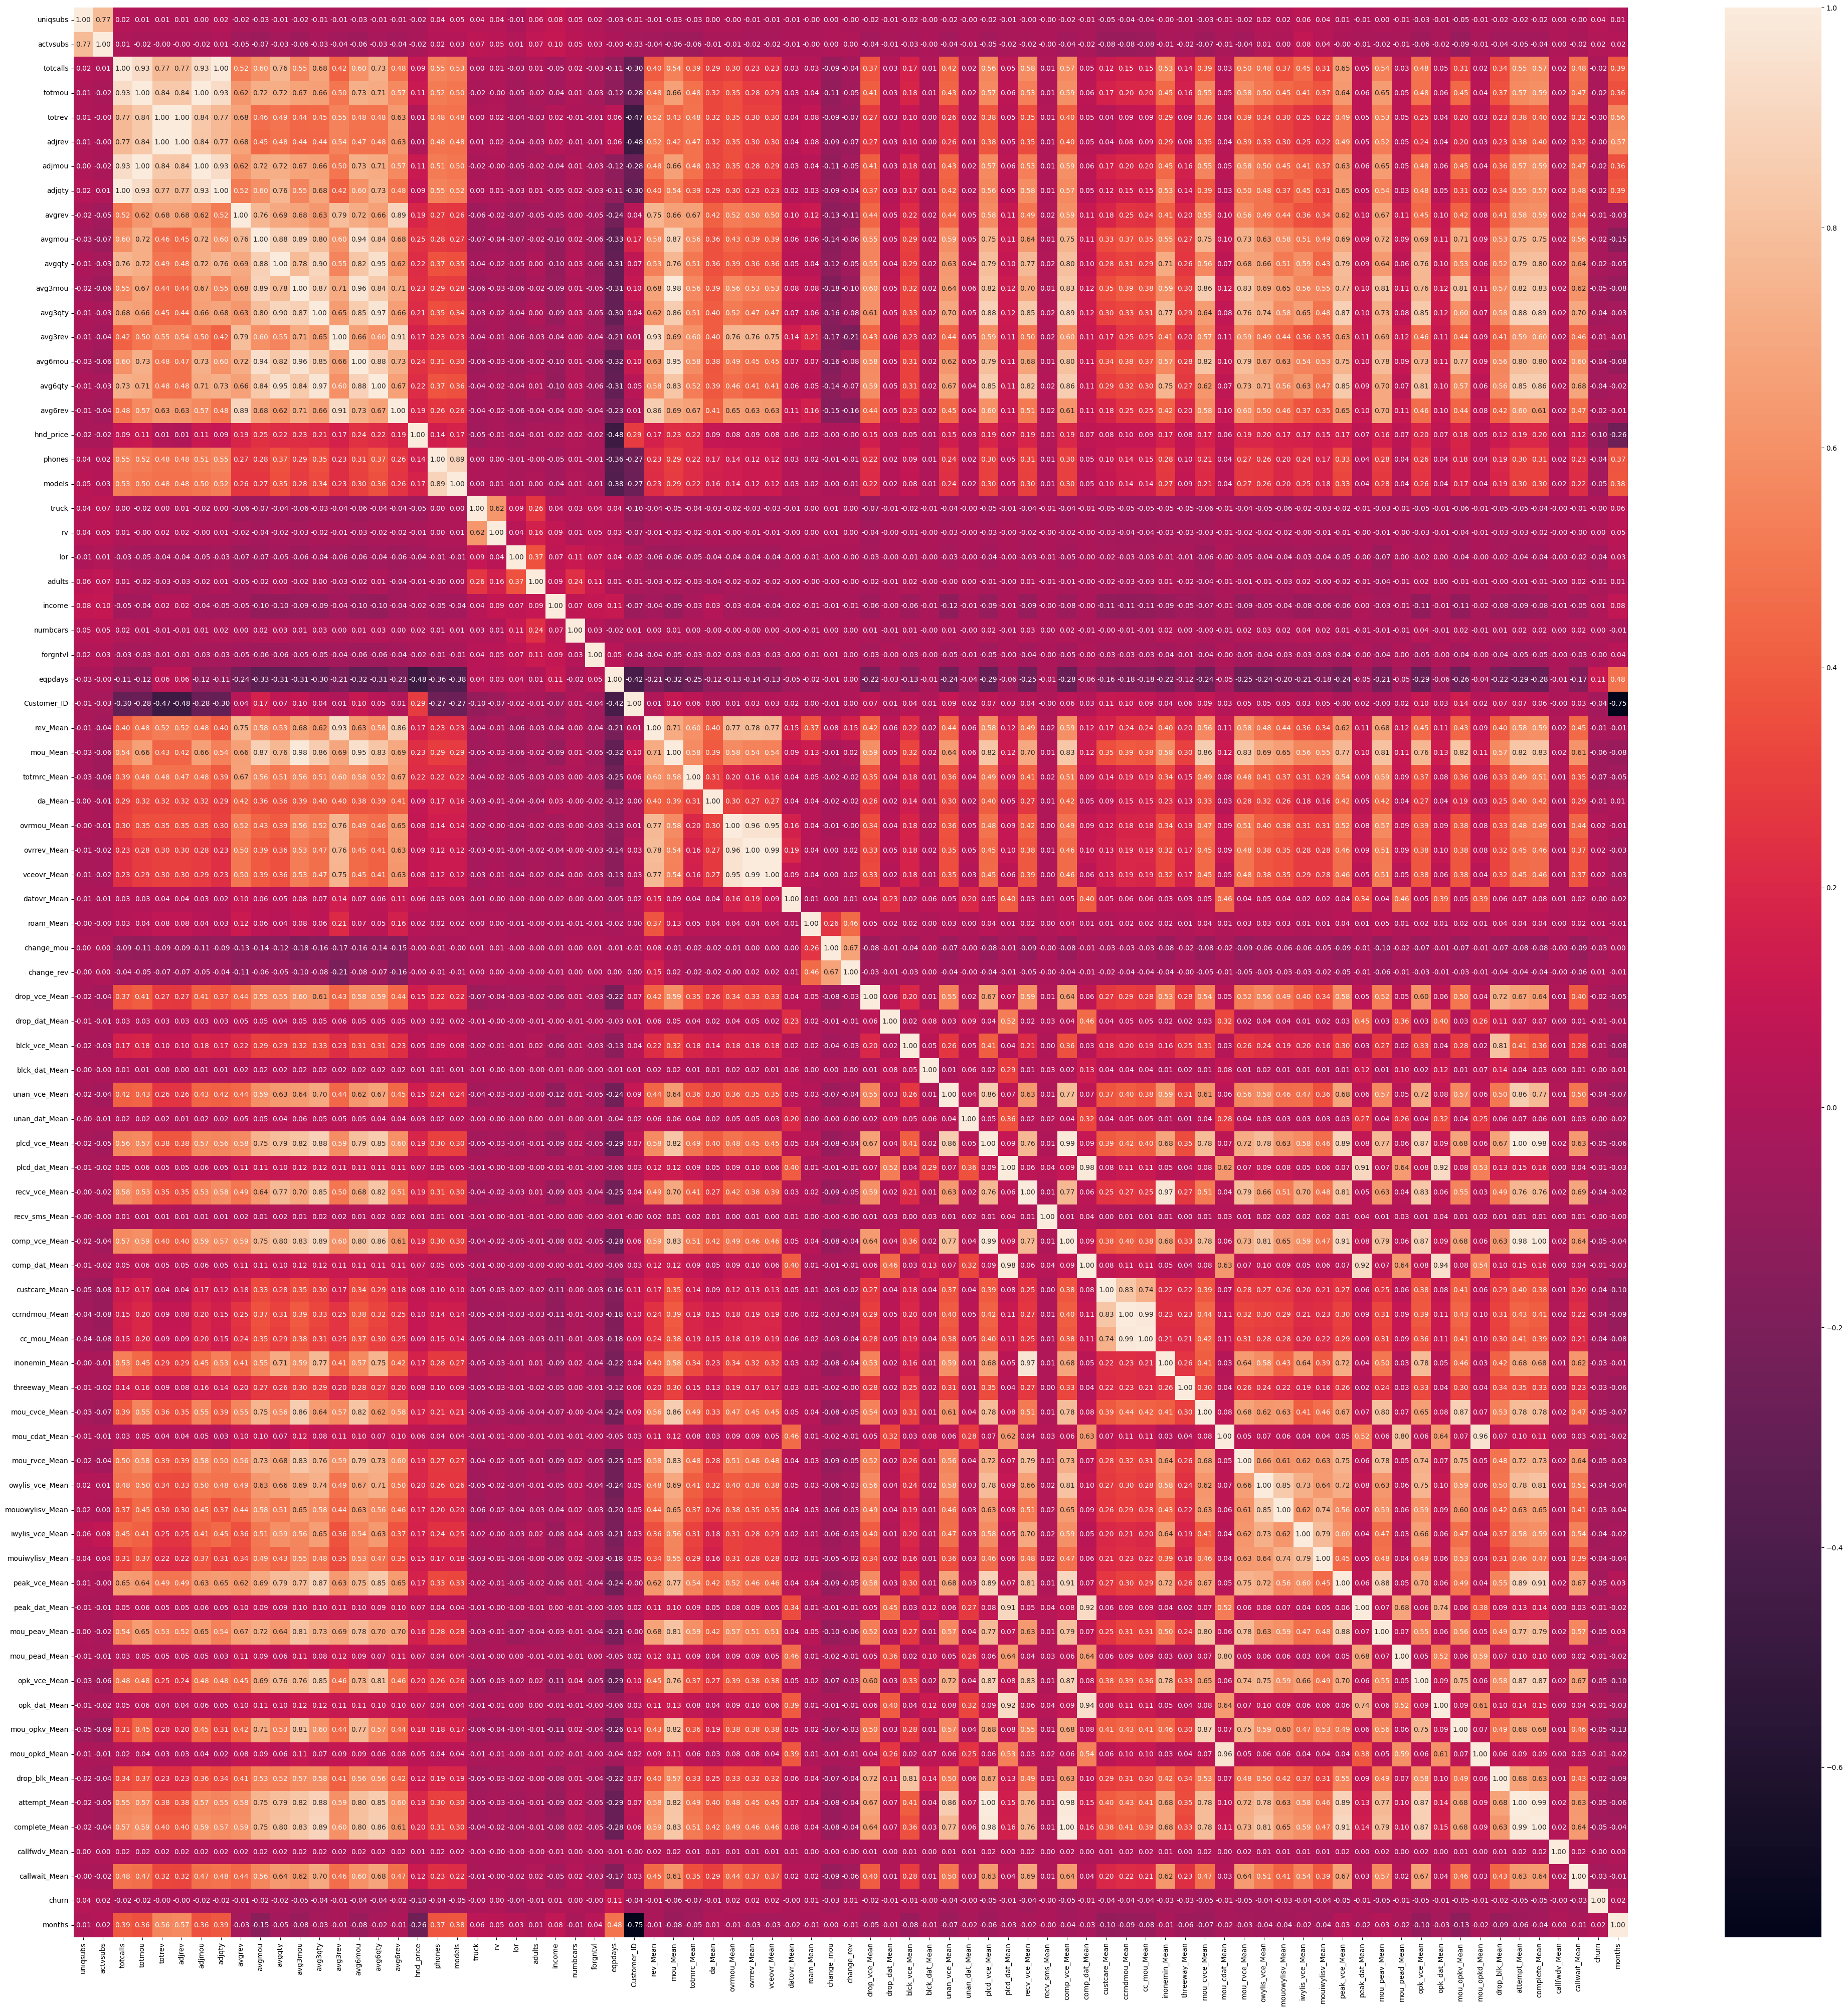

In [11]:
plt.figure(figsize=(50,50))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)
plt.show()

## Use Mask to delete all repetetive features and present high corr

In [12]:
ones_matrix=np.ones(shape=corr_matrix.shape).astype(bool)
ones_matrix

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(79, 79))

In [13]:
corr_matrix=corr_matrix.abs()
mask=np.tril(ones_matrix,k=-1)
corr_matrix=corr_matrix.where(mask)
corr_matrix=corr_matrix.unstack()
corr_matrix=corr_matrix.dropna()

In [14]:
corr_matrix

uniqsubs       actvsubs    0.774229
               totcalls    0.022994
               totmou      0.007589
               totrev      0.011241
               adjrev      0.008911
                             ...   
callfwdv_Mean  churn       0.002248
               months      0.002313
callwait_Mean  churn       0.031082
               months      0.010747
churn          months      0.020991
Length: 3081, dtype: float64

In [15]:
high_corr=corr_matrix[corr_matrix>0.90]

In [16]:
high_corr

totcalls       totmou           0.925686
               adjmou           0.925415
               adjqty           0.999798
totmou         adjmou           0.999747
               adjqty           0.925616
totrev         adjrev           0.998492
adjmou         adjqty           0.925759
avgmou         avg6mou          0.940631
avgqty         avg3qty          0.902196
               avg6qty          0.947249
avg3mou        avg6mou          0.962436
               mou_Mean         0.981123
avg3qty        avg6qty          0.967756
avg3rev        avg6rev          0.912807
               rev_Mean         0.927343
avg6mou        mou_Mean         0.945447
ovrmou_Mean    ovrrev_Mean      0.956056
               vceovr_Mean      0.953231
ovrrev_Mean    vceovr_Mean      0.994752
plcd_vce_Mean  comp_vce_Mean    0.985459
               attempt_Mean     0.998398
               complete_Mean    0.983280
plcd_dat_Mean  comp_dat_Mean    0.981303
               peak_dat_Mean    0.907054
               o

In [17]:
high_corr=high_corr.reset_index()
high_corr.columns=["col_1","col_2","Value"]
high_corr

,col_1,col_2,Value
0,totcalls,totmou,0.925686
1,totcalls,adjmou,0.925415
2,totcalls,adjqty,0.999798
3,totmou,adjmou,0.999747
4,totmou,adjqty,0.925616
5,totrev,adjrev,0.998492
6,adjmou,adjqty,0.925759
7,avgmou,avg6mou,0.940631
8,avgqty,avg3qty,0.902196
9,avgqty,avg6qty,0.947249


In [18]:
unique_cols_corr=np.unique(np.array(high_corr["col_1"]))

In [19]:
unique_cols_corr

array(['adjmou', 'attempt_Mean', 'avg3mou', 'avg3qty', 'avg3rev',
       'avg6mou', 'avgmou', 'avgqty', 'ccrndmou_Mean', 'comp_dat_Mean',
       'comp_vce_Mean', 'mou_cdat_Mean', 'ovrmou_Mean', 'ovrrev_Mean',
       'peak_vce_Mean', 'plcd_dat_Mean', 'plcd_vce_Mean', 'recv_vce_Mean',
       'totcalls', 'totmou', 'totrev'], dtype=object)

In [20]:
len(list(unique_cols_corr))

21

In [21]:
important_columns = [
    'churn', 
    'drop_vce_Mean', 
    'blck_vce_Mean', 
    'custcare_Mean', 
    'drop_blk_Mean', 
    'change_mou', 
    'change_rev', 
    'rev_Mean', 
    'totmrc_Mean', 
    'ovrrev_Mean', 
    'avgrev', 
    'eqpdays', 
    'months', 
    'hnd_price', 
    'mou_Mean', 
    'totcalls', 
    'roam_Mean', 
    'income', 
    'area'
]
found=[]
for x in important_columns:
    if x in unique_cols_corr:
        found.append(x)
        
print(found)

['ovrrev_Mean', 'totcalls']


In [22]:
unique_cols_corr=list(unique_cols_corr)
for c in found:
    unique_cols_corr.remove(c)

print(len(unique_cols_corr))

19


In [23]:
df_after_drop=full_data.drop(unique_cols_corr,axis=1)
df_after_drop.shape

(100000, 81)

In [24]:
numerical_cols=df_after_drop.select_dtypes(include=["number"])
corr_matrix=numerical_cols.corr()
ones_matrix=np.ones(shape=corr_matrix.shape).astype(bool)



In [25]:
corr_matrix=corr_matrix.abs()
mask=np.tril(ones_matrix,k=-1)
corr_matrix=corr_matrix.where(mask)
corr_matrix=corr_matrix.unstack()
corr_matrix=corr_matrix.dropna()
high_corr=corr_matrix[corr_matrix>0.75]
high_corr

uniqsubs         actvsubs           0.774229
totcalls         adjrev             0.771358
                 adjqty             0.999798
adjrev           adjqty             0.771261
avgrev           avg6rev            0.891557
                 rev_Mean           0.750815
avg6qty          mou_Mean           0.827084
                 opk_vce_Mean       0.814116
                 complete_Mean      0.860391
avg6rev          rev_Mean           0.857309
phones           models             0.890311
Customer_ID      months             0.754777
rev_Mean         ovrrev_Mean        0.776647
                 vceovr_Mean        0.772159
mou_Mean         mou_cvce_Mean      0.862251
                 mou_rvce_Mean      0.825693
                 mou_peav_Mean      0.811250
                 opk_vce_Mean       0.762730
                 mou_opkv_Mean      0.816294
                 complete_Mean      0.832570
ovrrev_Mean      vceovr_Mean        0.994752
blck_vce_Mean    drop_blk_Mean      0.811653
unan_vce_M

In [26]:
"vceovr_Mean" in important_columns

False

In [27]:
df_after_drop.drop("vceovr_Mean",axis=1,inplace=True)

## Preproccessing Nan values 

In [28]:
nan_sum=(df_after_drop.isna().sum())
nan_sum[nan_sum>0]

avg6qty              2839
avg6rev              2839
prizm_social_one     7388
area                   40
dualband                1
refurb_new              1
hnd_price             847
phones                  1
models                  1
hnd_webcap          10189
truck                1732
rv                   1732
ownrent             33706
lor                 30190
dwlltype            31909
marital              1732
adults              23019
infobase            22079
income              25436
numbcars            49366
HHstatin            37923
dwllsize            38308
forgntvl             1732
ethnic               1732
kid0_2               1732
kid3_5               1732
kid6_10              1732
kid11_15             1732
kid16_17             1732
creditcd             1732
eqpdays                 1
rev_Mean              357
mou_Mean              357
totmrc_Mean           357
da_Mean               357
ovrrev_Mean           357
datovr_Mean           357
roam_Mean             357
change_mou  

In [29]:
df_after_drop.drop(["dwllsize","HHstatin","numbcars","ownrent","lor","dwlltype"],axis=1,inplace=True)

In [30]:
cat_cols=df_after_drop.select_dtypes(include="object").columns
num_cols=df_after_drop.select_dtypes(include="number").columns
print(f"{len(list(cat_cols))}\n\n {len(list(num_cols))}")

17

 57


C:\Users\Access\AppData\Local\Temp\ipykernel_4820\1857159165.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_after_drop.select_dtypes(include="object").columns


In [31]:
print(cat_cols)
print(num_cols)

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'marital', 'infobase', 'ethnic',
       'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='str')
Index(['uniqsubs', 'actvsubs', 'totcalls', 'adjrev', 'adjqty', 'avgrev',
       'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'truck', 'rv',
       'adults', 'income', 'forgntvl', 'eqpdays', 'Customer_ID', 'rev_Mean',
       'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrrev_Mean', 'datovr_Mean',
       'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean',
       'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean',
       'unan_dat_Mean', 'recv_sms_Mean', 'custcare_Mean', 'cc_mou_Mean',
       'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_rvce_Mean',
       'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean',
       'mouiwylisv_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean',
       'opk_vce_Mean', '

## Preproccessing Steps

In [32]:
# pipline and column transformer for the data and select model to select the importance features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedShuffleSplit

In [45]:
df_after_drop.drop("Customer_ID",axis=1,inplace=True)

In [48]:
for x in df_after_drop.columns :
    print(f"{x}----->")
    print(len(list(df_after_drop[x].unique())))

uniqsubs----->
15
actvsubs----->
12
new_cell----->
3
crclscod----->
54
asl_flag----->
2
totcalls----->
12230
adjrev----->
75274
adjqty----->
12185
avgrev----->
14863
avg6qty----->
1377
avg6rev----->
452
prizm_social_one----->
6
area----->
20
dualband----->
5
refurb_new----->
3
hnd_price----->
18
phones----->
25
models----->
15
hnd_webcap----->
4
truck----->
3
rv----->
3
marital----->
6
adults----->
7
infobase----->
3
income----->
10
forgntvl----->
3
ethnic----->
18
kid0_2----->
3
kid3_5----->
3
kid6_10----->
3
kid11_15----->
3
kid16_17----->
3
creditcd----->
3
eqpdays----->
1556
rev_Mean----->
37469
mou_Mean----->
9731
totmrc_Mean----->
8492
da_Mean----->
173
ovrrev_Mean----->
12316
datovr_Mean----->
775
roam_Mean----->
5338
change_mou----->
7712
change_rev----->
32538
drop_vce_Mean----->
328
drop_dat_Mean----->
60
blck_vce_Mean----->
442
blck_dat_Mean----->
54
unan_vce_Mean----->
986
unan_dat_Mean----->
52
recv_sms_Mean----->
94
custcare_Mean----->
209
cc_mou_Mean----->
9231
inonemin_

In [ ]:
num_cols=df_after_drop.select_dtypes(include="number").columns
for x in num_cols :
    print(f"{x}----->")
    print(len(list(df_after_drop[x].unique())))

In [49]:
cat=df_after_drop.select_dtypes(include="object").columns
for x in cat_cols :
    print(f"{x}----->")
    print(len(list(df_after_drop[x].unique())))

new_cell----->
3
crclscod----->
54
asl_flag----->
2
prizm_social_one----->
6
area----->
20
dualband----->
5
refurb_new----->
3
hnd_webcap----->
4
marital----->
6
infobase----->
3
ethnic----->
18
kid0_2----->
3
kid3_5----->
3
kid6_10----->
3
kid11_15----->
3
kid16_17----->
3
creditcd----->
3


C:\Users\Access\AppData\Local\Temp\ipykernel_4820\3067100773.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=df_after_drop.select_dtypes(include="object").columns


In [50]:
splitter=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

for train_index,test_index in splitter.split(df_after_drop,df_after_drop["churn"]):
    strat_train=df_after_drop.loc[train_index]
    strat_test=df_after_drop.loc[test_index]

In [51]:
strat_train

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,adjrev,adjqty,avgrev,avg6qty,...,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
39301,1,1,U,BA,N,7810,2257.35,7789,118.81,441.0,...,63.333333,0.000000,97.650000,0.00,34.000000,180.333333,0.0,6.333333,1,20
51212,1,1,N,E4,Y,4333,1017.85,4326,59.87,277.0,...,122.333333,0.000000,761.720000,0.00,15.666667,179.666667,0.0,7.333333,0,19
6408,1,1,U,A,N,1928,1139.68,1873,39.30,70.0,...,16.000000,0.000000,24.690000,0.00,1.000000,64.000000,0.0,0.000000,0,33
57171,1,1,U,BA,N,85,290.96,82,29.10,8.0,...,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0,11
89299,1,1,U,EA,Y,2074,581.85,2061,96.98,344.0,...,215.000000,0.000000,895.386667,0.00,21.000000,349.000000,0.0,15.000000,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86167,1,1,U,AA,N,3076,975.38,3060,139.34,458.0,...,84.666667,0.000000,544.913333,0.00,21.333333,363.333333,0.0,8.666667,0,8
35165,1,1,U,AA,N,6178,2347.30,6158,111.78,298.0,...,107.666667,0.333333,649.106667,0.69,22.000000,126.666667,0.0,0.000000,1,22
28246,1,1,N,ZA,N,4580,1431.36,4562,68.16,330.0,...,102.000000,0.000000,178.870000,0.00,15.666667,225.333333,0.0,5.666667,0,23
32753,1,1,U,AA,N,162,494.98,161,23.57,8.0,...,0.333333,0.000000,0.873333,0.00,0.000000,4.666667,0.0,0.000000,0,23


In [52]:
strat_train_x=strat_train.drop("churn",axis=1)
strat_train_y=strat_train["churn"]

strat_test_x=strat_test.drop("churn",axis=1)
strat_test_y=strat_test["churn"]
num_cols=strat_train_x.select_dtypes(include="number").columns
cat_cols=strat_train_x.select_dtypes(include="object").columns

C:\Users\Access\AppData\Local\Temp\ipykernel_4820\2078512269.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=strat_train_x.select_dtypes(include="object").columns


In [53]:
num_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("std_scaler",StandardScaler()), 
])

cat_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoding",OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [54]:
col_transformer=ColumnTransformer(transformers=[
    ("number_preprocessing",num_pipe,num_cols),
    ("categorical_preprocessing",cat_pipe,cat_cols)
],verbose_feature_names_out=False)

In [55]:
pre_data_x=col_transformer.fit_transform(strat_train_x)
type(pre_data_x)

df_pre_data_x=pd.DataFrame(
    pre_data_x,
    columns=col_transformer.get_feature_names_out()
)

In [56]:
pre_data_test_x=col_transformer.transform(strat_test_x)

df_pre_data_test_x=pd.DataFrame(
    pre_data_test_x,
    columns=col_transformer.get_feature_names_out()
)

In [57]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(df_pre_data_x,strat_train_y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [58]:
from sklearn.metrics import classification_report

y_pred=model.predict(df_pre_data_test_x)

classification_report(strat_test_y,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.64      0.63      0.64     10088\n           1       0.63      0.64      0.64      9912\n\n    accuracy                           0.64     20000\n   macro avg       0.64      0.64      0.64     20000\nweighted avg       0.64      0.64      0.64     20000\n'

## Get the most important Features from the model

In [62]:
importance_dict = model.get_booster().get_score(importance_type='gain')

df_importance = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

total_gain = df_importance['Gain'].sum()
df_importance['Importance_Percentage'] = (df_importance['Gain'] / total_gain) * 100

df_top = df_importance.sort_values(by='Importance_Percentage', ascending=False).head(40)

top_col=list(df_top["Feature"])

df_top=df_top.reset_index()
df_top

,index,Feature,Gain,Importance_Percentage
0,61,refurb_new,36.967693,5.044060
1,16,eqpdays,36.638885,4.999196
2,54,months,31.334919,4.275496
3,8,hnd_price,20.378124,2.780495
4,18,mou_Mean,16.572369,2.261218
5,57,asl_flag,16.205637,2.211179
6,71,creditcd,15.330463,2.091766
7,0,uniqsubs,15.118066,2.062786
8,24,change_mou,15.027225,2.050391
9,19,totmrc_Mean,14.641624,1.997778


In [63]:
top_col

['refurb_new',
 'eqpdays',
 'months',
 'hnd_price',
 'mou_Mean',
 'asl_flag',
 'creditcd',
 'uniqsubs',
 'change_mou',
 'totmrc_Mean',
 'ovrrev_Mean',
 'crclscod',
 'mou_cvce_Mean',
 'marital',
 'totcalls',
 'ethnic',
 'avgrev',
 'adjqty',
 'change_rev',
 'drop_vce_Mean',
 'dualband',
 'phones',
 'models',
 'iwylis_vce_Mean',
 'mou_opkv_Mean',
 'mou_peav_Mean',
 'mouiwylisv_Mean',
 'actvsubs',
 'rev_Mean',
 'drop_blk_Mean',
 'cc_mou_Mean',
 'avg6rev',
 'opk_vce_Mean',
 'kid3_5',
 'roam_Mean',
 'inonemin_Mean',
 'complete_Mean',
 'income',
 'kid16_17',
 'avg6qty']

In [64]:
kl=[]
for x in top_col:
    for c in important_columns:
        if c in x :
            kl.append(x)
            
kl
            

['eqpdays',
 'months',
 'hnd_price',
 'mou_Mean',
 'change_mou',
 'totmrc_Mean',
 'ovrrev_Mean',
 'ovrrev_Mean',
 'totcalls',
 'avgrev',
 'change_rev',
 'drop_vce_Mean',
 'rev_Mean',
 'drop_blk_Mean',
 'cc_mou_Mean',
 'roam_Mean',
 'income']

In [65]:
print(len(kl))
print(len(important_columns))

17
19


In [66]:
# determine the msot important 15 --- 20 columns 


for c in important_columns: 
    if c not in top_col:
        top_col.append(c)
   

In [67]:
kl=[]
for x in top_col:
    for c in important_columns:
        if c in x :
            kl.append(x)
            
kl

['eqpdays',
 'months',
 'hnd_price',
 'mou_Mean',
 'change_mou',
 'totmrc_Mean',
 'ovrrev_Mean',
 'ovrrev_Mean',
 'totcalls',
 'avgrev',
 'change_rev',
 'drop_vce_Mean',
 'rev_Mean',
 'drop_blk_Mean',
 'cc_mou_Mean',
 'roam_Mean',
 'income',
 'churn',
 'blck_vce_Mean',
 'custcare_Mean',
 'area']

In [68]:
print(len(kl))
print(len(important_columns))

21
19


In [69]:
len(list(np.unique(np.array(top_col))))

44

In [70]:
# Read data again and pre it again and select the most important cols again

df_after_drop.shape

(100000, 73)

In [71]:
final_drop=df_after_drop.loc[:,top_col]
final_drop.shape

(100000, 44)

In [72]:


num_cols=list(final_drop.select_dtypes(include="number").columns)
cat_cols=list(final_drop.select_dtypes(include="object").columns)
print(len(num_cols))
print(len(cat_cols))



34
10


C:\Users\Access\AppData\Local\Temp\ipykernel_4820\3243219424.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=list(final_drop.select_dtypes(include="object").columns)


In [73]:
print(num_cols)
print(cat_cols)

['eqpdays', 'months', 'hnd_price', 'mou_Mean', 'uniqsubs', 'change_mou', 'totmrc_Mean', 'ovrrev_Mean', 'mou_cvce_Mean', 'totcalls', 'avgrev', 'adjqty', 'change_rev', 'drop_vce_Mean', 'phones', 'models', 'iwylis_vce_Mean', 'mou_opkv_Mean', 'mou_peav_Mean', 'mouiwylisv_Mean', 'actvsubs', 'rev_Mean', 'drop_blk_Mean', 'cc_mou_Mean', 'avg6rev', 'opk_vce_Mean', 'roam_Mean', 'inonemin_Mean', 'complete_Mean', 'income', 'avg6qty', 'churn', 'blck_vce_Mean', 'custcare_Mean']
['refurb_new', 'asl_flag', 'creditcd', 'crclscod', 'marital', 'ethnic', 'dualband', 'kid3_5', 'kid16_17', 'area']


## Split train,test to visualize data

In [53]:
splitter_2=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=44)

for train_index,test_index in splitter_2.split(final_drop,final_drop["churn"]):
    stratified_train = final_drop.loc[train_index]
    stratified_test = final_drop.loc[test_index]




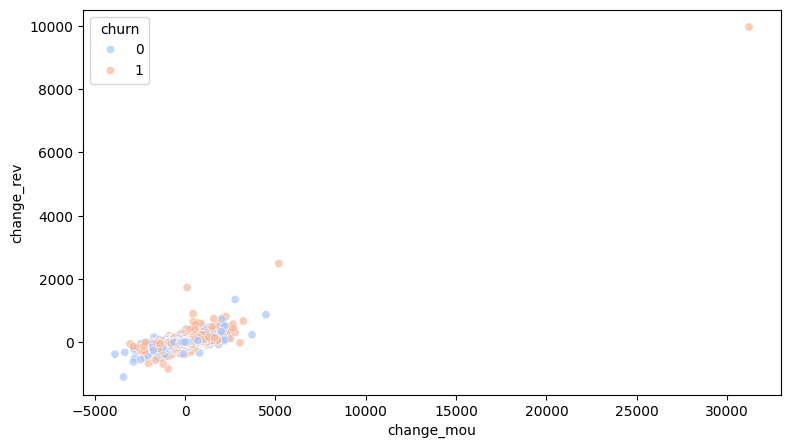

In [54]:
plt.figure(figsize=(9,5))
sns.scatterplot(x=stratified_train["change_mou"],y=stratified_train["change_rev"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()
# the more mins the higher money and that normal and there are people leave so maybe the price is high and there is outlier

In [55]:
print(stratified_train.shape)
stratified_train=stratified_train[stratified_train["change_mou"]<25000]
print(stratified_train.shape)

(95000, 23)
(94164, 23)


c:\Users\Access\Desktop\final_gci\.venv\Lib\site-packages\seaborn\distributions.py:474: RuntimeWarning: invalid value encountered in subtract
  edges = res[orient].to_numpy() - widths / 2


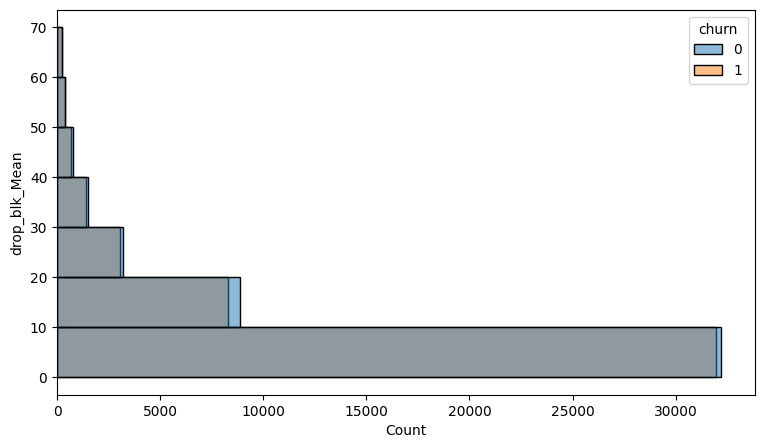

In [56]:
plt.figure(figsize=(9,5))
sns.histplot(data=stratified_train,y="drop_blk_Mean",hue="churn",bins=[0,10,20,30,40,50,60,70,np.inf])
plt.show()
# ممكن نستنتج ان عدد قطع المكلمات ملهوش علاقه قويه اوي لان زي مشيفين هنا عدد العملاء الباقيين اكتر من المغادرين رغم قطع المكلمات 

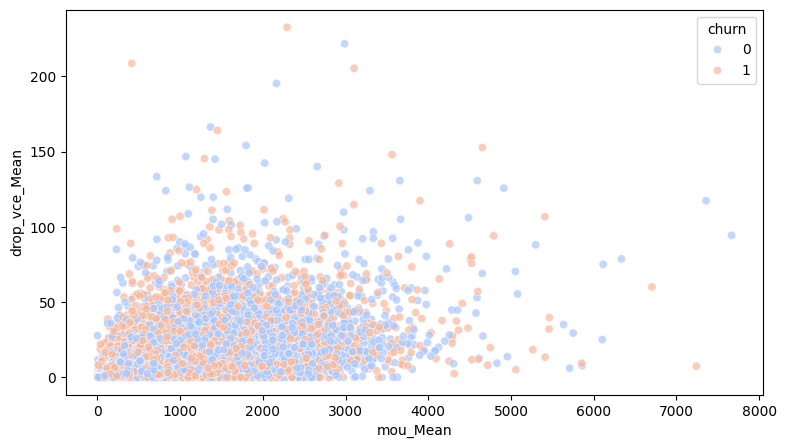

In [57]:
plt.figure(figsize=(9,5))
sns.scatterplot(y=stratified_train["drop_vce_Mean"],x=stratified_train["mou_Mean"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()

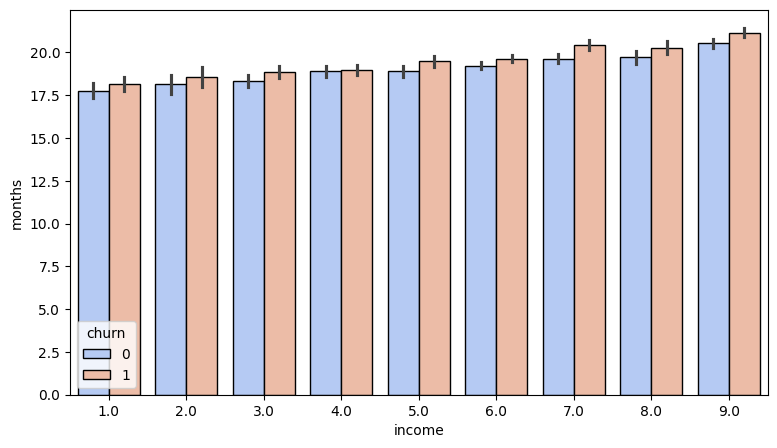

In [58]:
plt.figure(figsize=(9,5))
sns.barplot(y=stratified_train["months"],x=stratified_train["income"],palette="coolwarm",edgecolor="black",hue=stratified_train["churn"])
plt.show()
# there is no lear relation

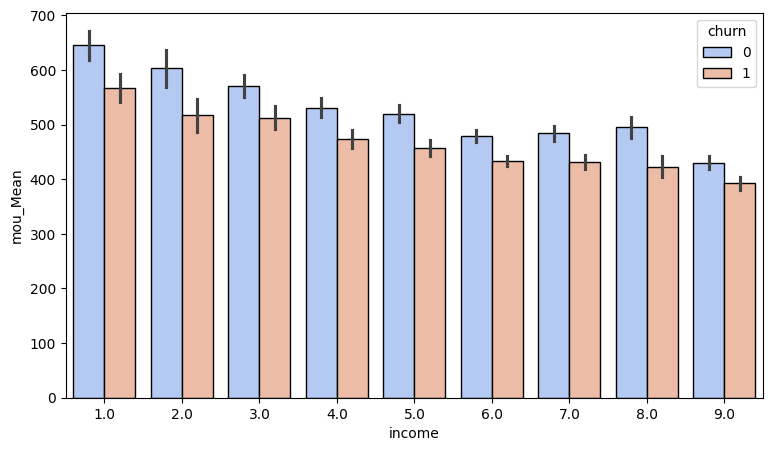

In [59]:
plt.figure(figsize=(9,5))
sns.barplot(y=stratified_train["mou_Mean"],x=stratified_train["income"],palette="coolwarm",edgecolor="black",hue=stratified_train["churn"])
plt.show()
# الناس اللي عندهم دخل مكالمتهم اقل 

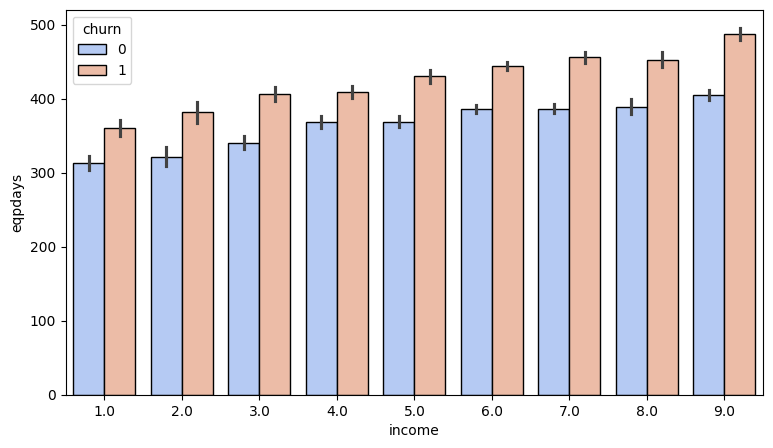

In [60]:
plt.figure(figsize=(9,5))
sns.barplot(y=stratified_train["eqpdays"],x=stratified_train["income"],palette="coolwarm",edgecolor="black",hue=stratified_train["churn"])
plt.show()
# الناس اللي تليفونها قديم و غنيه التليفون بيقعد معاهم كتير فبالتالي المفروض نركز على الناس اللي تليفونتهم قديمه و غنيه

In [61]:
stratified_train["refurb_new"].unique()

<StringArray>
['N', 'R', nan]
Length: 3, dtype: str

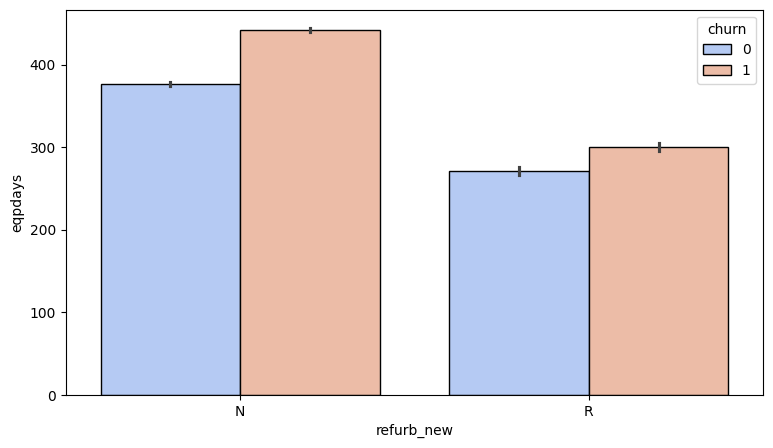

In [62]:
plt.figure(figsize=(9,5))
sns.barplot(y=stratified_train["eqpdays"],x=stratified_train["refurb_new"],palette="coolwarm",edgecolor="black",hue=stratified_train["churn"])
plt.show()
# معظم الناس اللي بتشتري جديد بتسيب الشركه و ده معناه انهم بيروحوا لشركات تانيه ربما عشان العروض 

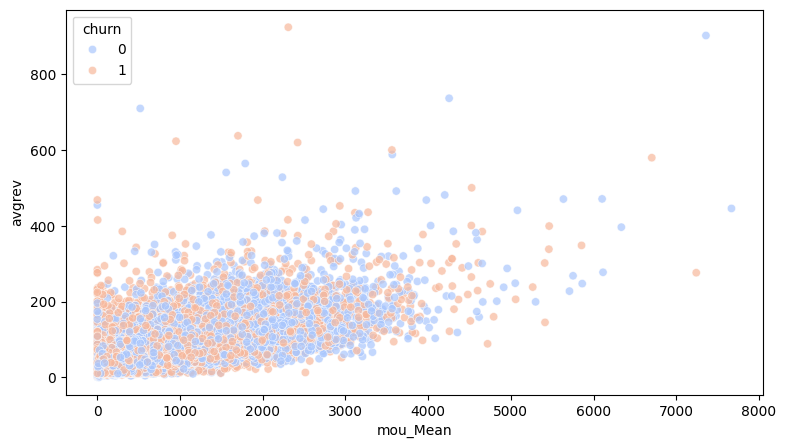

In [63]:
plt.figure(figsize=(9,5))
sns.scatterplot(y=stratified_train["avgrev"],x=stratified_train["mou_Mean"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()

In [64]:
stratified_train=stratified_train[(stratified_train["mou_Mean"]<10000) & (stratified_train["avgrev"]<800)]
stratified_train.shape

(94162, 23)

In [65]:
cat_mou_Mean=pd.cut(stratified_train["mou_Mean"],bins=6)
cat_mou_Mean


25277      (-7.668, 1277.958]
51388      (-7.668, 1277.958]
71098      (-7.668, 1277.958]
17084      (-7.668, 1277.958]
89017      (-7.668, 1277.958]
                 ...         
86063      (-7.668, 1277.958]
6142     (1277.958, 2555.917]
13963      (-7.668, 1277.958]
80685      (-7.668, 1277.958]
15012      (-7.668, 1277.958]
Name: mou_Mean, Length: 94162, dtype: category
Categories (6, interval[float64, right]): [(-7.668, 1277.958] < (1277.958, 2555.917] < (2555.917, 3833.875] < (3833.875, 5111.833] < (5111.833, 6389.792] < (6389.792, 7667.75]]

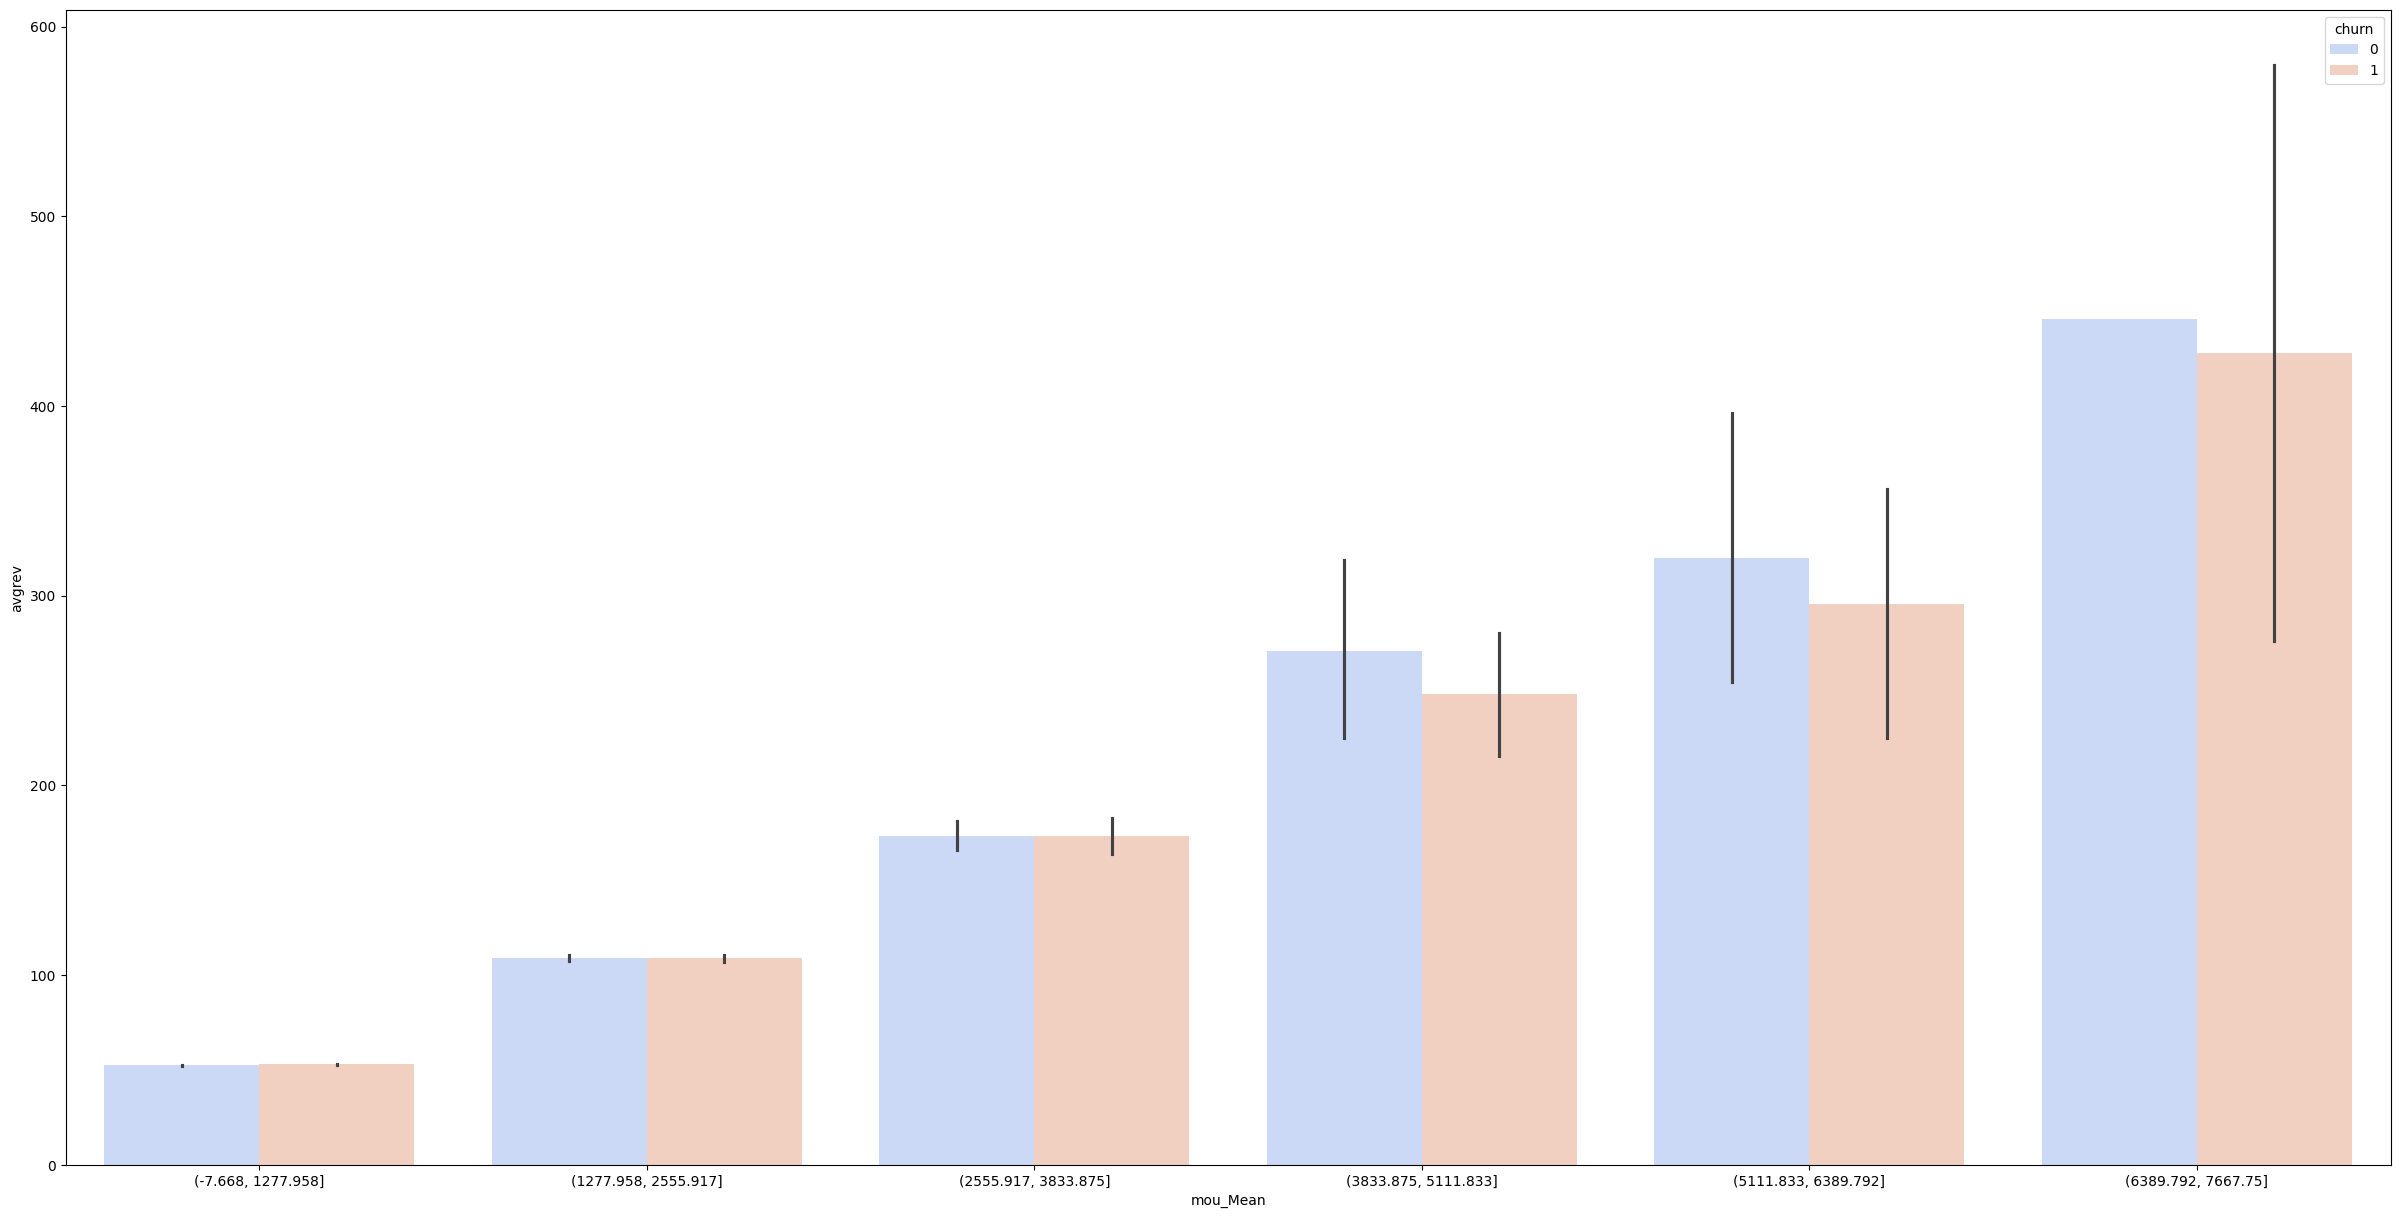

In [66]:
plt.figure(figsize=(30,15))
sns.barplot(x=cat_mou_Mean,y=stratified_train["avgrev"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()
# الناس اللي بتستخدم دقايق كتير و بتدفع اكتر قاعدين و ده معناه ان الباقات الكبيره كويسه 

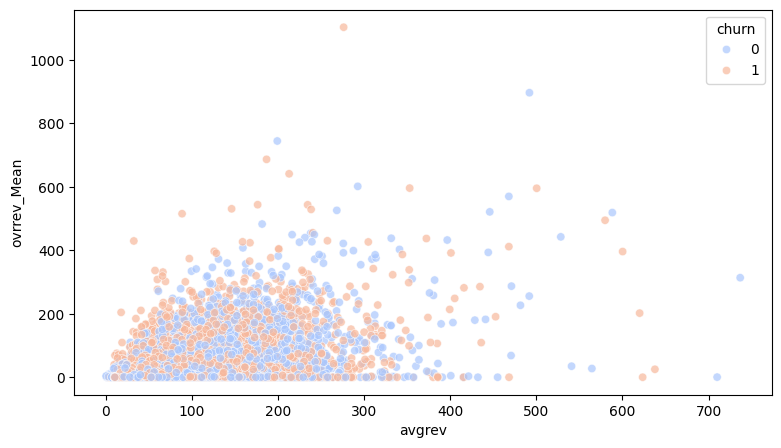

In [67]:
plt.figure(figsize=(9,5))
sns.scatterplot(y=stratified_train["ovrrev_Mean"],x=stratified_train["avgrev"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()

In [68]:
stratified_train=stratified_train[stratified_train["ovrrev_Mean"] < 800]

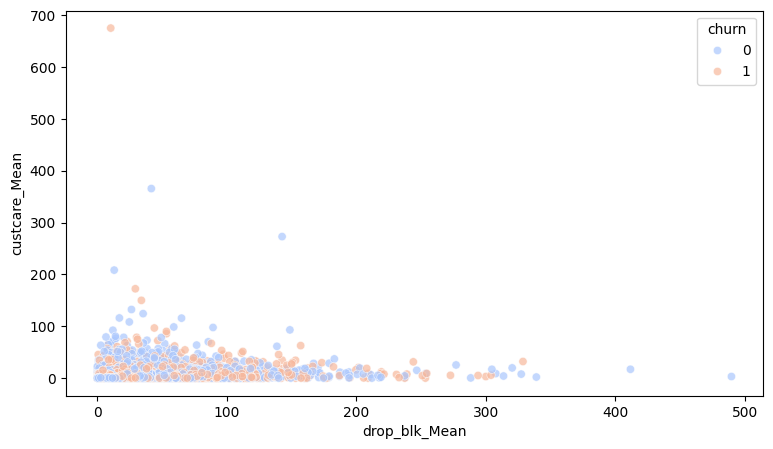

In [69]:
plt.figure(figsize=(9,5))
sns.scatterplot(y=stratified_train["custcare_Mean"],x=stratified_train["drop_blk_Mean"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()

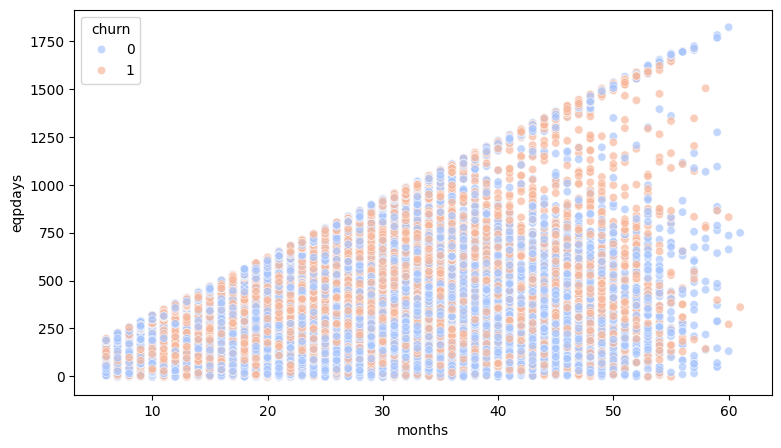

In [70]:
plt.figure(figsize=(9,5))
sns.scatterplot(x=stratified_train["months"],y=stratified_train["eqpdays"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()
# كل الشهور متزيد العملاء بيكون معاهم نفس التليفونات 

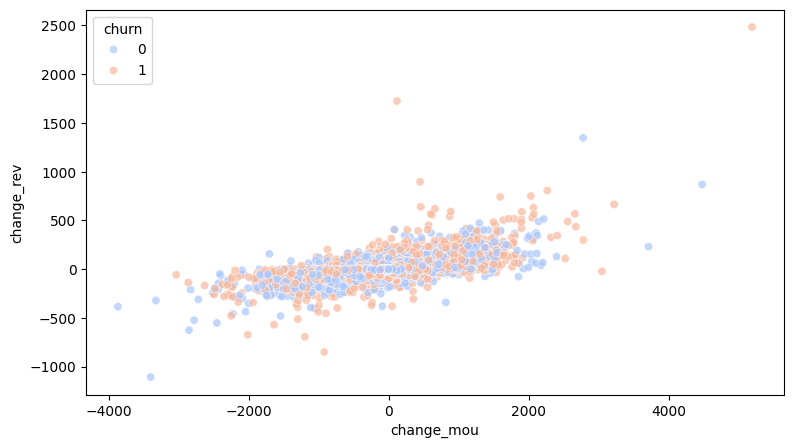

In [71]:

plt.figure(figsize=(9,5))
sns.scatterplot(x=stratified_train["change_mou"],y=stratified_train["change_rev"],alpha=0.7,hue=stratified_train["churn"],palette="coolwarm")
plt.show()
# الزياده في الدقائق اكيد يقابله زياده في الفاتوره و العلاقه الطرديه هنا لو رسمنالها خط مش هنلاقي slope عالي عشان كده مش مشكله اوي القصه ديه 

In [72]:
# now we have removed the outliers in the data 
stratified_train.shape

(94160, 23)

In [73]:
num_cols

['eqpdays',
 'months',
 'hnd_price',
 'mou_Mean',
 'totmrc_Mean',
 'change_mou',
 'churn',
 'drop_vce_Mean',
 'blck_vce_Mean',
 'custcare_Mean',
 'drop_blk_Mean',
 'change_rev',
 'rev_Mean',
 'ovrrev_Mean',
 'avgrev',
 'totcalls',
 'roam_Mean',
 'income']

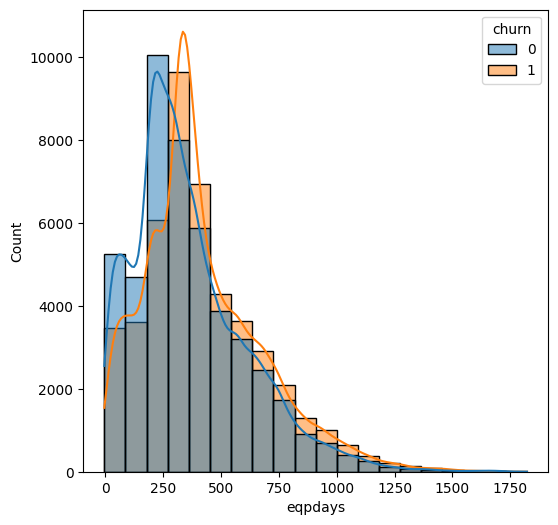

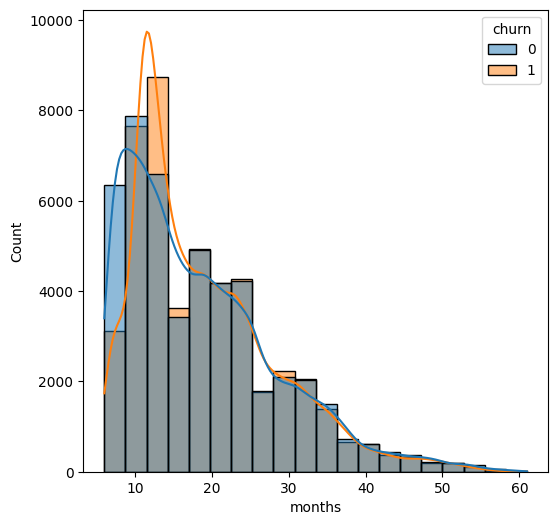

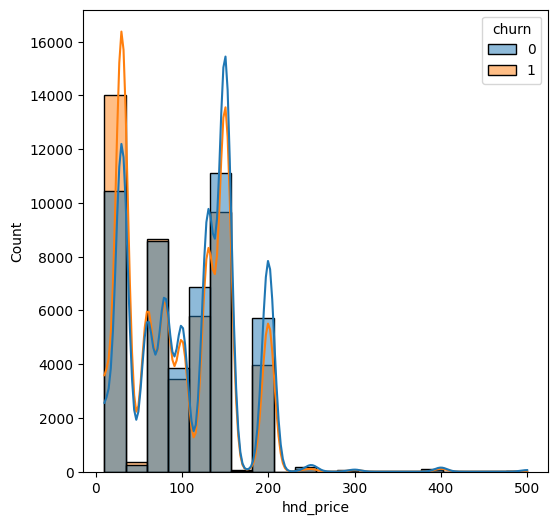

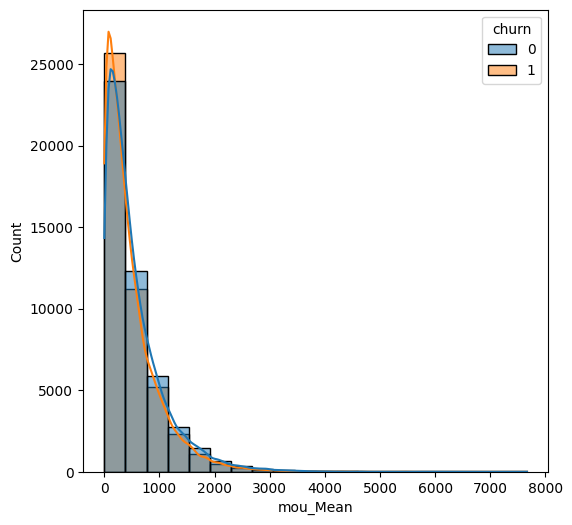

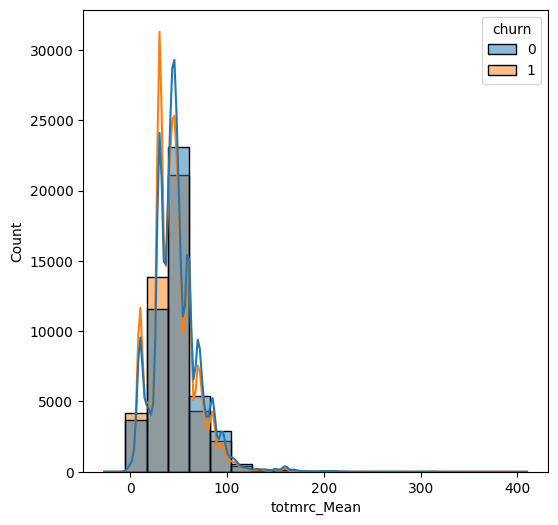

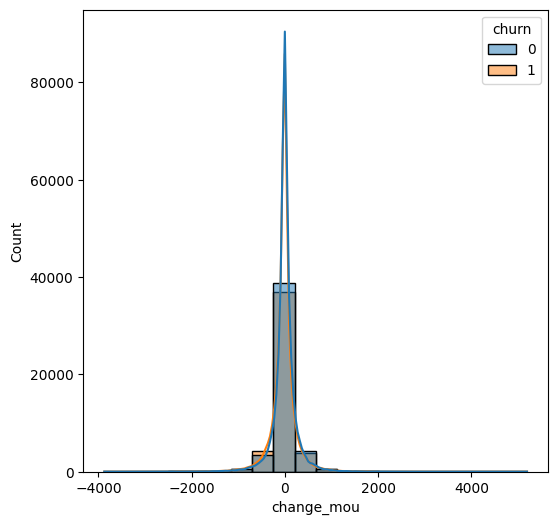

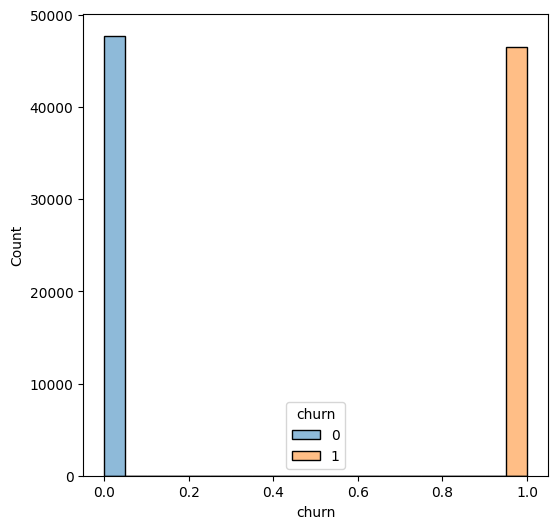

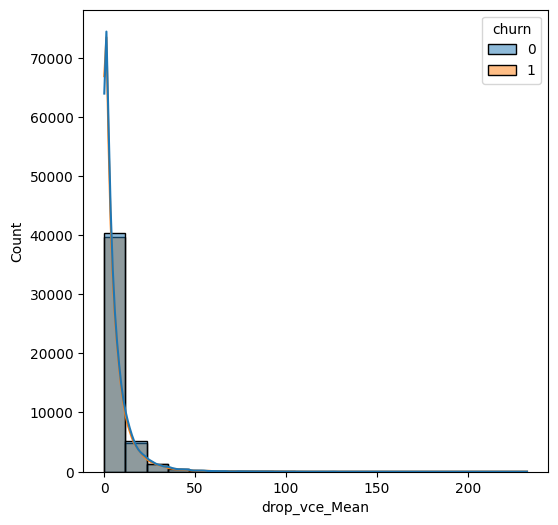

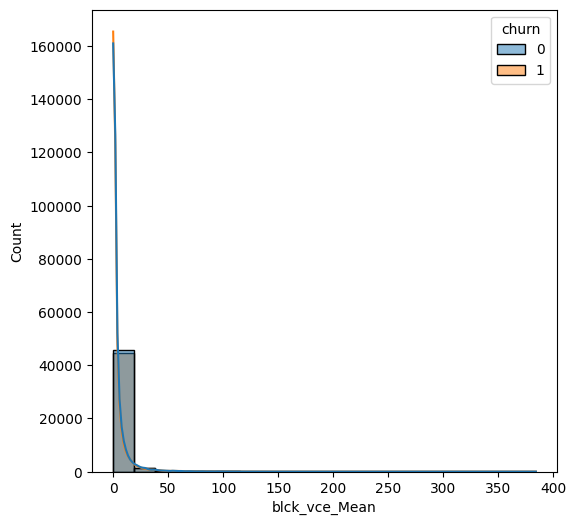

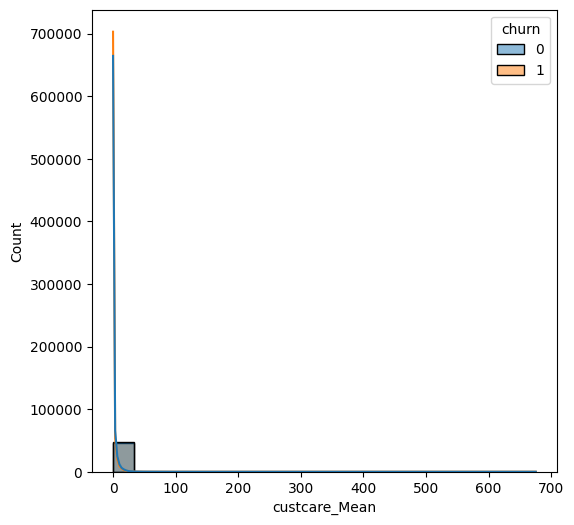

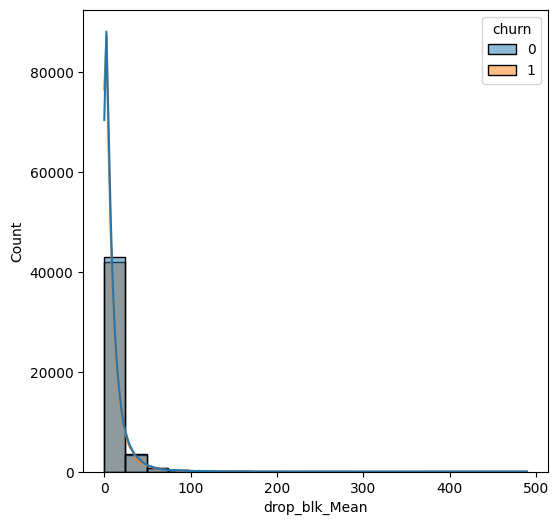

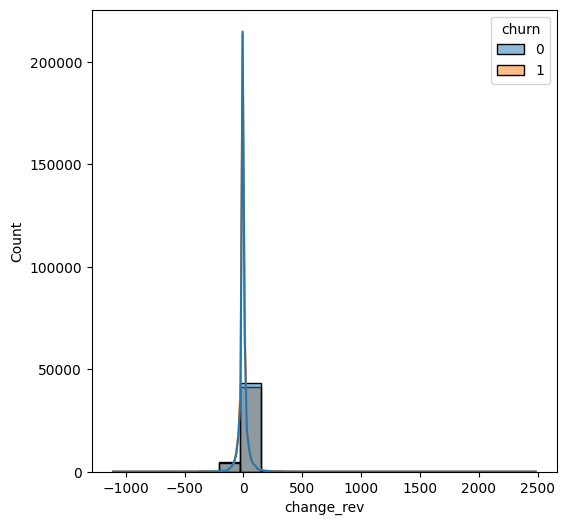

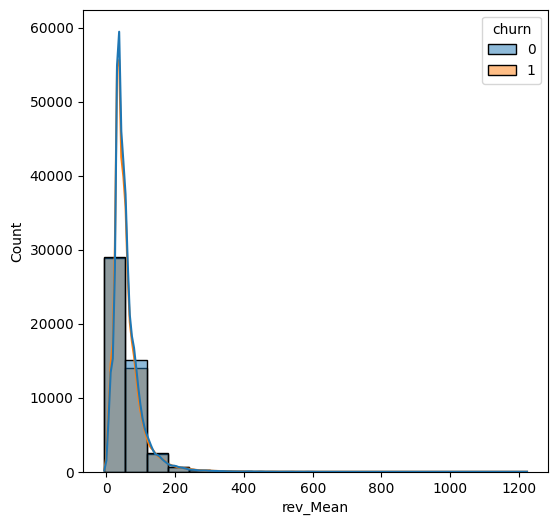

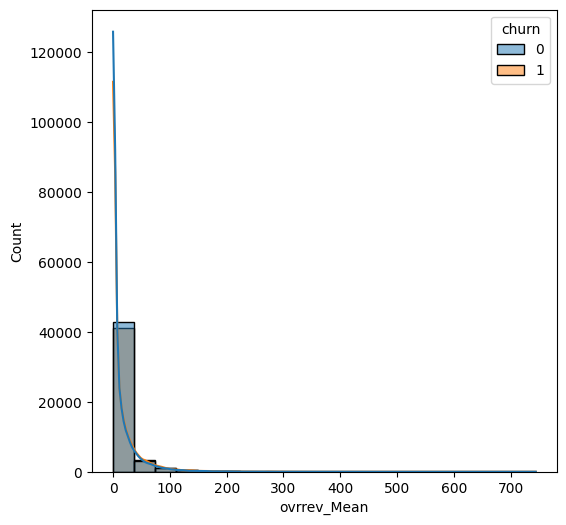

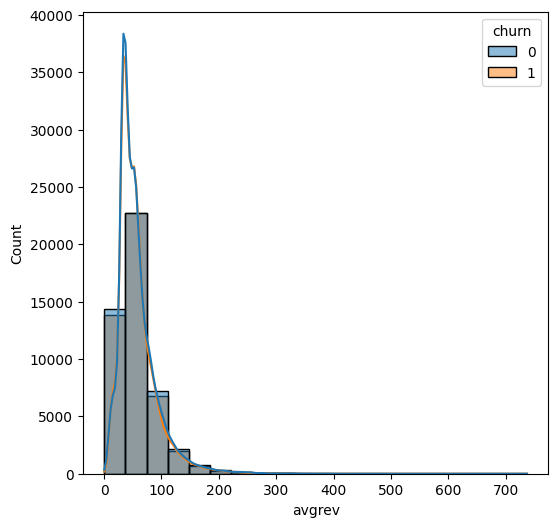

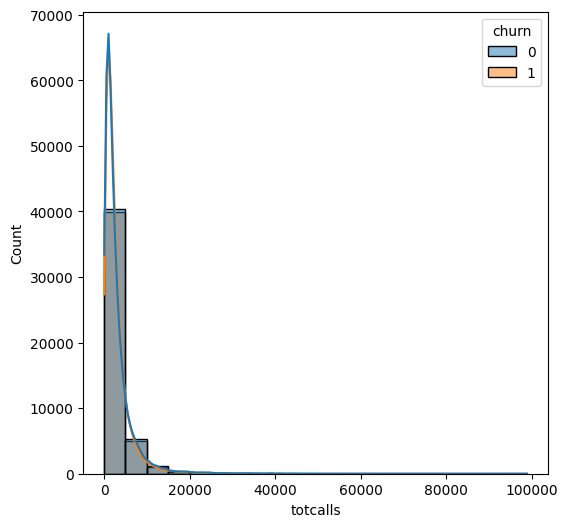

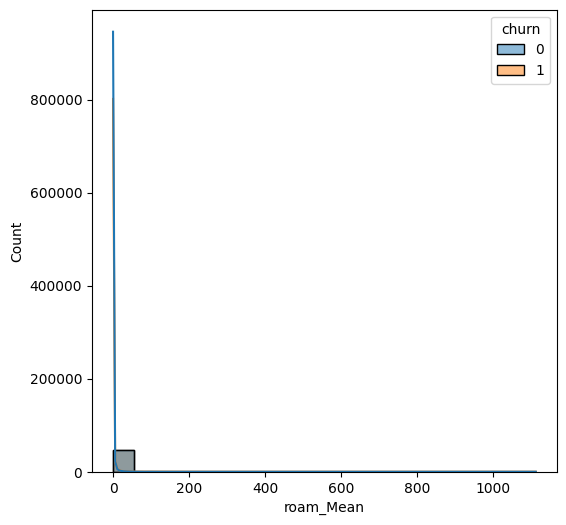

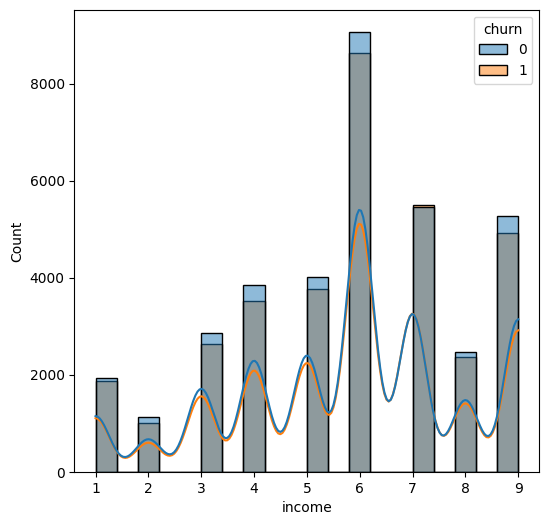

In [74]:
for x in num_cols:
    plt.figure(figsize=(6,6))
    sns.histplot(x=stratified_train[x],kde=True,bins=20,hue=stratified_train["churn"])
    plt.show()

In [75]:
# الناس اللي معاهم تليفونات رخيصه بيمشوا كتير على عكس اللي معاهم تليفونات غاليه
# فيه مشكله في الباقات الصغيره لان الناس للي بتمشي و استهلكهم قليل اكتر من الناس اللي استهلاكهم كبير
# الناس اللي اشتركهم الثابت قليل هم بردوا اللي بيمشوا اكتر و ده يدل ان فيه مشكله في الباقات الصغيره

## Prepare Data for the final training

In [76]:
strat_train.shape

(80000, 65)

In [54]:
final_drop.shape

(100000, 23)

In [56]:
final_drop.columns

Index(['eqpdays', 'refurb_new', 'months', 'hnd_price', 'asl_flag', 'mou_Mean',
       'totmrc_Mean', 'creditcd', 'change_mou', 'crclscod', 'churn',
       'drop_vce_Mean', 'blck_vce_Mean', 'custcare_Mean', 'drop_blk_Mean',
       'change_rev', 'rev_Mean', 'ovrrev_Mean', 'avgrev', 'totcalls',
       'roam_Mean', 'income', 'area'],
      dtype='str')

In [57]:
final_drop_new=final_drop.copy()

In [59]:
final_drop["change_mou"]=final_drop["change_mou"].clip(upper=5000)
final_drop["mou_Mean"]=final_drop["mou_Mean"].clip(upper=6500)
final_drop["drop_vce_Mean"]=final_drop["drop_vce_Mean"].clip(upper=175)
final_drop["avgrev"]=final_drop["avgrev"].clip(upper=600)
final_drop["ovrrev_Mean"]=final_drop["ovrrev_Mean"].clip(upper=600)
final_drop["drop_blk_Mean"]=final_drop["drop_blk_Mean"].clip(upper=350)
final_drop["custcare_Mean"]=final_drop["custcare_Mean"].clip(upper=200)
final_drop["change_rev"]=final_drop["change_rev"].clip(upper=1000)
final_drop["eqpdays"]=final_drop["eqpdays"].clip(upper=1150)
final_drop["months"]=final_drop["months"].clip(upper=55)
final_drop["hnd_price"]=final_drop["hnd_price"].clip(upper=200)
final_drop["totcalls"]=final_drop["totcalls"].clip(upper=20000)
final_drop["totmrc_Mean"]=final_drop["totmrc_Mean"].clip(upper=150)

In [61]:
final_drop.drop(["income","area","crclscod"],axis=1,inplace=True)

In [62]:
final_drop.shape

(100000, 20)

In [77]:
cat_cols=stratified_train.select_dtypes(include="object").columns
print(len(cat_cols))
for x in cat_cols:
    print(f"\n\n\n\n {stratified_train[x].unique()}\n\n {x}")

5




 <StringArray>
['N', 'R', nan]
Length: 3, dtype: str

 refurb_new




 <StringArray>
['N', 'Y']
Length: 2, dtype: str

 asl_flag




 <StringArray>
['Y', 'N', nan]
Length: 3, dtype: str

 creditcd




 <StringArray>
['CA', 'AA', 'BA', 'EA', 'Z2', 'E4', 'GA', 'A2',  'A', 'DA', 'V1', 'ZA',  'B',
  'C',  'U', 'Z4', 'IF', 'B2', 'JF', 'C2',  'I', 'D4',  'J',  'D',  'K', 'CY',
 'TP',  'M', 'ZY',  'E',  'Y', 'U1',  'W',  'Z',  'G',  'H', 'Z5', 'E2', 'EM',
 'C5', 'GY', 'CC', 'D5', 'EC',  'O', 'Z1', 'D2',  'L', 'P1', 'A3', 'EF',  'V',
  'S', 'ZF']
Length: 54, dtype: str

 crclscod




 <StringArray>
[        'CALIFORNIA NORTH AREA',     'DC/MARYLAND/VIRGINIA AREA',
                  'MIDWEST AREA',                  'CHICAGO AREA',
           'ATLANTIC SOUTH AREA',                  'HOUSTON AREA',
 'NORTHWEST/ROCKY MOUNTAIN AREA',              'NEW ENGLAND AREA',
              'LOS ANGELES AREA',                   'DALLAS AREA',
                'TENNESSEE AREA',                'SOUTHWEST A

C:\Users\Access\AppData\Local\Temp\ipykernel_7352\3593444931.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=stratified_train.select_dtypes(include="object").columns


In [78]:
nan_sum=stratified_train.isna().sum()
nan_sum

eqpdays              1
refurb_new           1
months               0
hnd_price          791
asl_flag             0
mou_Mean             0
totmrc_Mean          0
creditcd          1623
change_mou           0
crclscod             0
churn                0
drop_vce_Mean        0
blck_vce_Mean        0
custcare_Mean        0
drop_blk_Mean        0
change_rev           0
rev_Mean             0
ovrrev_Mean          0
avgrev               0
totcalls             0
roam_Mean            0
income           23922
area                38
dtype: int64

In [79]:
stratified_train=stratified_train.drop(["income","area","crclscod"],axis=1)
stratified_test=stratified_test.drop(["income","area","crclscod"],axis=1)

from sklearn.preprocessing import OneHotEncoder


In [80]:
num_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("std_scaler",StandardScaler()), 
])

cat_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoding",OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

## Stope Next Step

In [81]:
stratified_train.shape

(94160, 20)

In [82]:
stratified_test.shape

(5000, 20)

In [83]:
x_values_train=stratified_train.drop("churn",axis=1)
y_values_train=stratified_train["churn"]
x_values_test=stratified_test.drop("churn",axis=1)
y_values_test=stratified_test["churn"]

In [84]:
num_cols=x_values_train.select_dtypes(include="number").columns
cat_cols=x_values_train.select_dtypes(include="object").columns

C:\Users\Access\AppData\Local\Temp\ipykernel_7352\1388984883.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=x_values_train.select_dtypes(include="object").columns


In [85]:
len(list(num_cols))

16

In [86]:
col_transformer=ColumnTransformer(transformers=[
    ("number_preprocessing",num_pipe,num_cols),
    ("categorical_preprocessing",cat_pipe,cat_cols)
],verbose_feature_names_out=False)

In [87]:
pre_x_values_train=col_transformer.fit_transform(x_values_train)
df_x_values_train=pd.DataFrame(pre_x_values_train,columns=col_transformer.get_feature_names_out())

pre_x_values_test=col_transformer.fit_transform(x_values_test)
df_x_values_test=pd.DataFrame(pre_x_values_test,columns=col_transformer.get_feature_names_out())

print(df_x_values_test.head())
print(df_x_values_train.head())

    eqpdays    months  hnd_price  mou_Mean  totmrc_Mean  change_mou  \
0 -0.204426 -0.813787  -1.165931  2.464306     1.249311    0.963771   
1 -1.422875  0.109968   0.793070  0.822444     1.162895    0.660440   
2  0.426210  0.109968  -1.165931  0.230297    -0.695053    0.792661   
3 -0.255032 -0.813787  -0.676180 -0.621395    -0.262972    0.131556   
4 -0.994666 -0.608508  -1.165931  0.256732     0.601190    0.883077   

   drop_vce_Mean  blck_vce_Mean  custcare_Mean  drop_blk_Mean  ...  \
0       2.844295       3.290449      -0.137648       3.877138  ...   
1      -0.058213       0.003260      -0.298365      -0.031637  ...   
2      -0.213013       0.323962      -0.191221       0.126293  ...   
3      -0.677414      -0.344166      -0.298365      -0.604135  ...   
4       0.793189      -0.130365      -0.298365       0.303965  ...   

   ovrrev_Mean    avgrev  totcalls  roam_Mean  refurb_new_N  refurb_new_R  \
0    -0.353178  1.233561  1.287012   0.118192           1.0           0.0  

In [88]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.001,
    max_depth=16,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(df_x_values_train,y_values_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [89]:
from sklearn.metrics import classification_report

y_pred=model.predict(df_x_values_test)

classification_report(y_values_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.57      0.81      0.67      2522\n           1       0.65      0.37      0.47      2478\n\n    accuracy                           0.59      5000\n   macro avg       0.61      0.59      0.57      5000\nweighted avg       0.61      0.59      0.57      5000\n'

In [90]:
importance_dict = model.get_booster().get_score(importance_type='gain')

df_importance = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

total_gain = df_importance['Gain'].sum()
df_importance['Importance_Percentage'] = (df_importance['Gain'] / total_gain) * 100

df_top = df_importance.sort_values(by='Importance_Percentage', ascending=False)

top_col=list(df_top["Feature"])

df_top=df_top.reset_index()
df_top

,index,Feature,Gain,Importance_Percentage
0,1,months,11.351525,9.312129
1,18,asl_flag_N,9.142295,7.499806
2,19,asl_flag_Y,8.812979,7.229654
3,0,eqpdays,8.193895,6.721794
4,16,refurb_new_N,7.638191,6.265926
5,2,hnd_price,6.253444,5.129961
6,17,refurb_new_R,6.208711,5.093264
7,3,mou_Mean,5.297525,4.345781
8,4,totmrc_Mean,5.259582,4.314654
9,5,change_mou,4.793050,3.931939


In [91]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(df_x_values_train,y_values_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [92]:
from sklearn.metrics import classification_report

y_pred=model.predict(df_x_values_test)

classification_report(y_values_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.58      0.59      0.58      2522\n           1       0.58      0.58      0.58      2478\n\n    accuracy                           0.58      5000\n   macro avg       0.58      0.58      0.58      5000\nweighted avg       0.58      0.58      0.58      5000\n'

In [93]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [94]:
model.fit(df_x_values_train,y_values_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [95]:

y_pred=model.predict(df_x_values_test)

classification_report(y_values_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.65      0.54      0.59      2522\n           1       0.60      0.70      0.65      2478\n\n    accuracy                           0.62      5000\n   macro avg       0.63      0.62      0.62      5000\nweighted avg       0.63      0.62      0.62      5000\n'

In [96]:
importances = model.feature_importances_
feature_imp = pd.Series(importances, index=df_x_values_train.columns).sort_values(ascending=False)

In [97]:
feature_imp

eqpdays          0.183035
months           0.157246
mou_Mean         0.079830
change_mou       0.071861
totmrc_Mean      0.061071
hnd_price        0.060474
totcalls         0.050822
avgrev           0.049086
change_rev       0.046971
rev_Mean         0.041880
ovrrev_Mean      0.038237
drop_blk_Mean    0.026083
custcare_Mean    0.023127
drop_vce_Mean    0.021726
blck_vce_Mean    0.017966
roam_Mean        0.015746
asl_flag_N       0.013604
asl_flag_Y       0.010081
refurb_new_R     0.009893
refurb_new_N     0.008918
creditcd_Y       0.006363
creditcd_N       0.005980
dtype: float64

## Add New Column

In [85]:
from sklearn.base import BaseEstimator, TransformerMixin
class MyTransformer(BaseEstimator,TransformerMixin):
    def __init__(self,failure_rate_feature=True,network_frustration_feature=True,bill_shock_ratio_feature=True,eqp_age_ratio_feature=True):
        
        self.failure_rate_feature=failure_rate_feature
        self.network_frustration_feature=network_frustration_feature
        self.bill_shock_ratio_feature=bill_shock_ratio_feature
        self.eqp_age_ratio_feature=eqp_age_ratio_feature
    
    def fit (self,X,y=None):
        return self
    
    def transform(self,X):
        
        edits=[]
        
        
        if self.failure_rate_feature:
            failure_rate=X["drop_blk_Mean"] / (X["totcalls"]+0.00001)
            failure_rate.name="failure_rate"
            edits.append(failure_rate)
            
        
            
            
        if self.network_frustration_feature:
            network_frustration=X["drop_vce_Mean"] * X["custcare_Mean"]
            network_frustration.name="network_frustration"
            edits.append(network_frustration)
        
   
        
        if self.bill_shock_ratio_feature:
            bill_shock_ratio=X["ovrrev_Mean"]/(X["totmrc_Mean"]+0.00001)
            bill_shock_ratio.name="bill_shock_ratio"
            
            edits.append(bill_shock_ratio)
        
    
        
        if self.eqp_age_ratio_feature:
            eqp_age_ratio=X["eqpdays"] / (X["months"]+0.0001)
            eqp_age_ratio.name="eqp_age_ratio"
            edits.append(eqp_age_ratio)
        
        
        
        if edits:
            X=pd.concat([X] + edits,axis=1)
        return X
            
            
        
            

In [65]:
from sklearn.preprocessing import OneHotEncoder

In [66]:
num_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("std_scaler",StandardScaler()), 
])

cat_pipe=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoding",OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [67]:
from sklearn.compose import  make_column_selector
col_transformer=ColumnTransformer(transformers=[
    ("number_preprocessing",num_pipe,make_column_selector(dtype_include=["number"])),
    ("categorical_preprocessing",cat_pipe,make_column_selector(dtype_include=["object"]))
],verbose_feature_names_out=False)

In [69]:
from sklearn.model_selection import RandomizedSearchCV

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
full_pipe=Pipeline([
    ("feature_engineering",MyTransformer()),
    ("preprocessing",col_transformer),
    ("classifier",RandomForestClassifier(random_state=42))
])

In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [74]:
param_distribution={
    "feature_engineering__failure_rate_feature":[True,False],
    "feature_engineering__network_frustration_feature":[True,False],
    "feature_engineering__bill_shock_ratio_feature":[True,False],
    "feature_engineering__eqp_age_ratio_feature":[True,False],
    "classifier__n_estimators":[100,150],
    "classifier__max_depth":[5,10],
    "classifier__min_samples_split":[12,16,32],
    "classifier__class_weight":[None]
    
}

In [79]:
random_search=RandomizedSearchCV(
    estimator=full_pipe,
    param_distributions=param_distribution,
    n_iter=20,
    scoring="f1",
    random_state=42,
    n_jobs=1,
    cv=5
)

In [76]:
f_splitter=StratifiedShuffleSplit(n_splits=1,test_size=0.2,)

for train_index,test_index in splitter_2.split(final_drop,final_drop["churn"]):
    stratified_train = final_drop.loc[train_index]
    stratified_test = final_drop.loc[test_index]

In [77]:
strat_x_train=stratified_train.drop("churn",axis=1)
strat_x_test=stratified_test.drop("churn",axis=1)
strat_y_train=stratified_train["churn"]
strat_y_test=stratified_test["churn"]

In [78]:
for_random_x=final_drop.drop("churn",axis=1)
for_random_y=final_drop["churn"]

In [80]:
random_search.fit(for_random_x,for_random_y)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score (F1):", random_search.best_score_)

Best Parameters: {'feature_engineering__network_frustration_feature': True, 'feature_engineering__failure_rate_feature': True, 'feature_engineering__eqp_age_ratio_feature': True, 'feature_engineering__bill_shock_ratio_feature': True, 'classifier__n_estimators': 150, 'classifier__min_samples_split': 12, 'classifier__max_depth': 5, 'classifier__class_weight': None}
Best CV Score (F1): 0.605267647633367


In [115]:
full_pipe_random=Pipeline([
    ("feature_engineering",MyTransformer(network_frustration_feature=False,failure_rate_feature=True,eqp_age_ratio_feature=True,bill_shock_ratio_feature=True)),
    ("preprocessing",col_transformer),
    ("classifier",RandomForestClassifier(random_state=42,n_estimators=300,class_weight=None,max_depth=10,min_samples_split=16))
])



In [116]:
full_pipe_random.fit(x_values_train,y_values_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,failure_rate_feature,True
,bill_shock_ratio_feature,True
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number_preprocessing', ...), ('categorical_preprocessing', ...)]"


In [118]:
y_pred=full_pipe_random.predict(x_values_test)

classification_report(y_values_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.65      0.55      0.60      2522\n           1       0.60      0.70      0.65      2478\n\n    accuracy                           0.62      5000\n   macro avg       0.63      0.62      0.62      5000\nweighted avg       0.63      0.62      0.62      5000\n'

In [119]:
import joblib
joblib.dump(full_pipe_random, 'telecom_churn_pipeline_model.pkl')

['telecom_churn_pipeline_model.pkl']

In [81]:
full_pipe_2=Pipeline([
    ("feature_engineering",MyTransformer()),
    ("preprocessing",col_transformer),
    ("classifier",XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [82]:
param_distribution = {
    "feature_engineering__failure_rate_feature": [True, False],
    "feature_engineering__network_frustration_feature": [True, False],
    "feature_engineering__bill_shock_ratio_feature": [True, False],
    "feature_engineering__eqp_age_ratio_feature": [True, False],
    "classifier__n_estimators": [100, 150, 200,300],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.05, 0.001],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9]
}

In [83]:
random_search_xgb = RandomizedSearchCV(
    estimator=full_pipe_2,
    param_distributions=param_distribution,
    n_iter=20,
    cv=5,
    scoring='f1',
    refit='f1',
    random_state=42,
    n_jobs=1
)

In [84]:
random_search_xgb.fit(for_random_x,for_random_y)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiated

In [85]:
print("Best Parameters:", random_search_xgb.best_params_)
print("Best CV Score (F1):", random_search_xgb.best_score_)

Best Parameters: {'feature_engineering__network_frustration_feature': False, 'feature_engineering__failure_rate_feature': False, 'feature_engineering__eqp_age_ratio_feature': False, 'feature_engineering__bill_shock_ratio_feature': True, 'classifier__subsample': 0.9, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.9}
Best CV Score (F1): 0.6023528011860818


In [132]:
full_pipe_xgb=Pipeline([
    ("feature_engineering",MyTransformer(network_frustration_feature=False,failure_rate_feature=True,eqp_age_ratio_feature=True,bill_shock_ratio_feature=True)),
    ("preprocessing",col_transformer),
    ("classifier",XGBClassifier(random_state=42, eval_metric='logloss',subsample=0.8,n_estimators=100,min_child_weight=3,max_depth=4,learning_rate=0.01,colsample_bytree=0.7))
])

In [133]:
full_pipe_xgb.fit(x_values_train, y_values_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,failure_rate_feature,True
,bill_shock_ratio_feature,True
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number_preprocessing', ...), ('categorical_preprocessing', ...)]"


In [134]:
y_pred = full_pipe_xgb.predict(x_values_test)
classification_report(y_values_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.64      0.49      0.56      2522\n           1       0.58      0.72      0.64      2478\n\n    accuracy                           0.61      5000\n   macro avg       0.61      0.61      0.60      5000\nweighted avg       0.61      0.61      0.60      5000\n'

In [135]:
joblib.dump(full_pipe_xgb, 'telecom_churn_pipeline_model_xgb.pkl')

['telecom_churn_pipeline_model_xgb.pkl']

In [75]:
final_drop.shape

(100000, 44)

In [77]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter=StratifiedShuffleSplit(n_splits=1,test_size=0.2)
for train_index,test_index in splitter.split(final_drop,final_drop["churn"]):
    strat_train=final_drop.loc[train_index]
    strat_test=final_drop.loc[test_index]
    
print(strat_train.shape)
print(strat_test.shape)

(80000, 44)
(20000, 44)


In [78]:
num_cols=strat_train.select_dtypes(include="number").columns
cat_cols=strat_train.select_dtypes(include="object").columns

C:\Users\Access\AppData\Local\Temp\ipykernel_4820\2719254767.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=strat_train.select_dtypes(include="object").columns


In [89]:
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.pipeline import Pipeline

In [90]:
from sklearn.preprocessing import OrdinalEncoder,RobustScaler
from sklearn.impute import SimpleImputer

In [91]:
num_pipe=Pipeline(steps=[
    ("num_impute",SimpleImputer(strategy="median")),
    ("Scaler",RobustScaler()),
    
])

cat_pipe=Pipeline(steps=[
    ("cat_impute",SimpleImputer(strategy="most_frequent")),
    ("encoding",OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [111]:
col_transformer=ColumnTransformer(
    transformers=[
        ("num_transform",num_pipe,make_column_selector(dtype_include="number")),
        ("cat_transform",cat_pipe,make_column_selector(dtype_include="object"))
    ]
)


In [112]:
from sklearn.decomposition import PCA

In [135]:
from catboost import CatBoostClassifier
final_pipe=Pipeline(
    steps=[
            ("feature_engineering",MyTransformer(network_frustration_feature=False,failure_rate_feature=True,eqp_age_ratio_feature=True,bill_shock_ratio_feature=True)),
            ("transformer",col_transformer),
            # ("pca",PCA(n_components=0.80)),
            ("model",CatBoostClassifier(
    iterations=1500,
    learning_rate=0.04,
    depth=6,
    l2_leaf_reg=3,
    eval_metric='Logloss',
    random_state=42,
    verbose=100))
    ]
)

In [136]:
strat_train_x=strat_train.drop("churn",axis=1)
strat_test_x=strat_test.drop("churn",axis=1)
strat_train_y=strat_train["churn"]
strat_test_y=strat_test["churn"]

In [137]:
final_pipe.fit(strat_train_x,strat_train_y)

0:	learn: 0.6912593	total: 165ms	remaining: 4m 7s
100:	learn: 0.6469695	total: 7.94s	remaining: 1m 49s
200:	learn: 0.6365275	total: 15.2s	remaining: 1m 38s
300:	learn: 0.6289101	total: 23.8s	remaining: 1m 34s
400:	learn: 0.6211188	total: 31.3s	remaining: 1m 25s
500:	learn: 0.6146275	total: 38.7s	remaining: 1m 17s
600:	learn: 0.6089618	total: 46.1s	remaining: 1m 8s
700:	learn: 0.6035654	total: 53.8s	remaining: 1m 1s
800:	learn: 0.5984927	total: 1m 1s	remaining: 54s
900:	learn: 0.5937294	total: 1m 9s	remaining: 46.2s
1000:	learn: 0.5893240	total: 1m 16s	remaining: 38.3s
1100:	learn: 0.5849339	total: 1m 24s	remaining: 30.6s
1200:	learn: 0.5806732	total: 1m 32s	remaining: 23s
1300:	learn: 0.5767542	total: 1m 39s	remaining: 15.2s
1400:	learn: 0.5727754	total: 1m 47s	remaining: 7.58s
1499:	learn: 0.5690368	total: 1m 54s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,network_frustration_feature,False
,failure_rate_feature,True
,bill_shock_ratio_feature,True
,eqp_age_ratio_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"


In [138]:
from sklearn.metrics import classification_report

In [139]:
y_pred=final_pipe.predict(strat_test_x)

classification_report(strat_test_y,y_pred)


'              precision    recall  f1-score   support\n\n           0       0.64      0.63      0.64     10088\n           1       0.63      0.65      0.64      9912\n\n    accuracy                           0.64     20000\n   macro avg       0.64      0.64      0.64     20000\nweighted avg       0.64      0.64      0.64     20000\n'